### Plot snippets of behavior data

In [43]:
%reload_ext autoreload
%autoreload 2

[13:27:28][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:27:28][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [3]:
import spyglass as nd
import pandas as pd
import numpy as np
import xarray as xr
import os
import pickle
import matplotlib.pyplot as plt

from spyglass.common import TaskEpoch
from spyglass.spikesorting.v0 import (SortGroup, 
                                    SpikeSortingRecording,SpikeSortingRecordingSelection)
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition, TrackGraph

[2026-03-06 09:55:32,252][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
from spyglass.shijiegu.Analysis_SGU import ChangeofMind,LFPBandArtifact,TrialChoice,EpochPos,MUA,get_linearization_map,MUATheta
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.shijiegu.load import load_run_sessions, load_decode

In [5]:
from spyglass.shijiegu.changeOfMind import find_direction_dot_product, vectors, nodes

[09:55:46][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:55:46][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:55:46][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:55:46][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackG

In [6]:
from spyglass.shijiegu.changeOfMind_figures.example_snippet import (
    plot_behavior, plot_decode_spiking, save_data)

[09:55:47][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[09:55:47][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [40]:
proportion_threshold = 0.1
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1'

#day, epoch_num, session_name, trial number, number of change of mind, -tx, +ty
examples = [('molly20220419_.nwb', 2, "06_Seq2Session3", 50, 0, (-7, 4.5), True),
            ('julio20230808_.nwb', 3, '08_Seq2Session4', 27, 0, (-3.5,7), True)
           ]

### load and save example data

In [27]:
# use 1D decode, causal, 2ms bin
param1 = {"variant":"behavior",
         "likelihood": False, "causal": True, "use_1d_decode": True,
          "imu_name": "big_acc_bias",
          "classifier_param_name": 'default_decoding_gpu_4armMaze'}


In [38]:
for example in examples:
    save_data(example, proportion_threshold, output_folder, **param1)

[2026-03-06 10:22:53,026][WARNING]: Skipped checksum for file with hash: e8703a04-8754-18a0-e41c-6d63b3f62567, and path: /stelmo/nwb/analysis/molly20220419_JAAO0YQCEB.nwb
[2026-03-06 10:22:53,035][WARNING]: Skipped checksum for file with hash: e8703a04-8754-18a0-e41c-6d63b3f62567, and path: /stelmo/nwb/analysis/molly20220419_JAAO0YQCEB.nwb
[2026-03-06 10:22:53,042][WARNING]: Skipped checksum for file with hash: e8703a04-8754-18a0-e41c-6d63b3f62567, and path: /stelmo/nwb/analysis/molly20220419_JAAO0YQCEB.nwb
[2026-03-06 10:22:53,047][WARNING]: Skipped checksum for file with hash: e8703a04-8754-18a0-e41c-6d63b3f62567, and path: /stelmo/nwb/analysis/molly20220419_JAAO0YQCEB.nwb


*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220419_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220419_ 2         02_Seq2Session pos 1 valid ti
molly20220419_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220419_ 4         04_Seq2Session pos 3 valid ti
molly20220419_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220419_ 6         06_Seq2Session pos 5 valid ti
molly20220419_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220419_ 8         08_Seq2Session pos 7 valid ti
molly20220419_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220419_ 10        10_Seq2Session pos 9 valid ti
molly20220419_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)

molly20220419_.nwb 06_Seq2Session3 pos 5 valid times
epoch name 06_Seq2Session3
epoch_pos_name pos 5 valid times


[2026-03-06 10:22:53,078][WARNING]: Skipped checksum for file with hash: 157e7920-776e-5730-102e-1548ec07cb65, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_857VVN9Z7V.nwb
[2026-03-06 10:22:53,087][WARNING]: Skipped checksum for file with hash: 157e7920-776e-5730-102e-1548ec07cb65, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_857VVN9Z7V.nwb
[2026-03-06 10:22:53,094][WARNING]: Skipped checksum for file with hash: 157e7920-776e-5730-102e-1548ec07cb65, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_857VVN9Z7V.nwb
[2026-03-06 10:22:53,099][WARNING]: Skipped checksum for file with hash: 157e7920-776e-5730-102e-1548ec07cb65, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_857VVN9Z7V.nwb
[2026-03-06 10:22:53,228][WARNING]: Skipped checksum for file with hash: db487cf4-2333-efe8-29ac-1076ba3bbf42, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_DYIFV8Y8E8.nwb
[2026-03-06 10:22:53,235][WARNING]: Skipped checksum for file with hash: db

Data successfully pickled and saved to longdata_variantbehavior_molly_molly20220419_.nwb_06_Seq2Session3_trial50.pkl


### plot

#### shorter snippets

In [34]:
output_path = output_folder

In [35]:
from spyglass.shijiegu.ripple_add_replay import select_subset_helper
from spyglass.shijiegu.theta_singleUnit import smoothen_mua, get_theta_from_mua, get_theta_from_cc

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/longdata_variantbehavior_molly_molly20220419_.nwb_06_Seq2Session3_trial50.pkl
plotting
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/longdata_variantbehavior_julio_julio20230808_.nwb_08_Seq2Session4_trial27.pkl
plotting


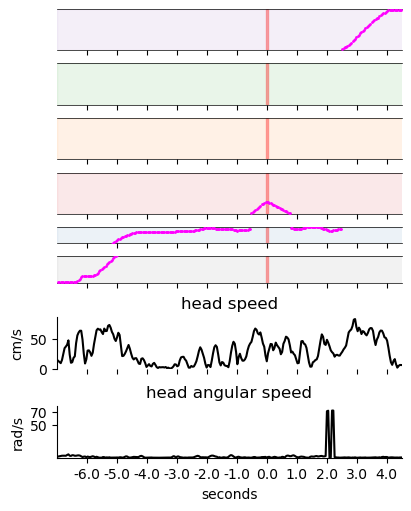

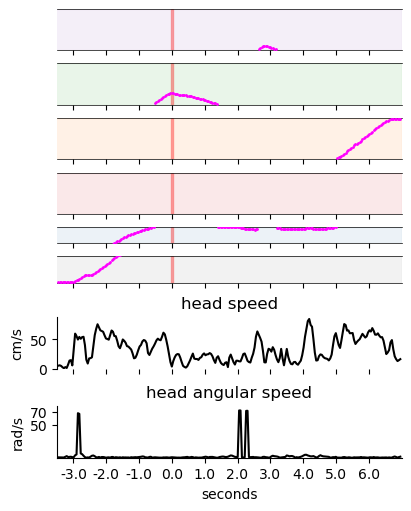

In [52]:
figure_folder = "/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/"
head_direction_lim = 80
for example in examples:#examples_short:
    nwb_copy_file_name, epoch_num, session_name, t, ind, (tx, ty), type_long = example
    animal = nwb_copy_file_name[:5]
    prefix = "longdata"

    for param in [param1]:#params:
        variant = param["variant"]
        plot_data_filename = f"{prefix}_variant{variant}_{animal}_{nwb_copy_file_name}_{session_name}_trial{t}.pkl"

        try:
            output_path = os.path.join(output_folder,plot_data_filename)
            with open(output_path, 'rb') as file:
                data = pickle.load(file)
            print(f"Data loaded from {output_path}")
        except:
            print(f"Problem with {nwb_copy_file_name, epoch_num, session_name}")
            continue

        # mua_smoothened = smoothen_mua(data["mua_subset"], moving_ave_window = 0.02) # 20 ms window smoothened
        # if theta_type == 'mua':
        #     theta_subset = get_theta_from_mua(mua_smoothened, 0)
        # elif theta_type == 'cc':
        #     print("loading cc theta")
        #     theta_subset = get_theta_from_cc(nwb_copy_file_name, session_name)
        #     theta_subset = select_subset_helper(theta_subset, data["plottimes"])
        #     print("finished cc theta")

        print("plotting")
        
        plot_behavior(data["plottimes"],data["linear_position_subset"],data["decode"],
                        data["head_speed_subset"],data["angular_speed_subset"],
                        head_direction_lim = head_direction_lim,
                        savefolder=data["output_folder"], savename=figure_folder+plot_data_filename+str(head_direction_lim),
                        t0 = data["t0"], plot_len = 4,
                        turnaround = np.array([data["t0"]-0.03,data["t0"]+0.03]).reshape((1,-1)),
                        )

In [53]:
data["angular_speed_subset"]

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 164)
Coordinates:
  * time     (time) float64 1kB 1.65e+09 1.65e+09 1.65e+09 ... 1.65e+09 1.65e+09
Data variables:
    0        (time) float64 1kB 2.529 1.996 0.9716 ... -1.373 -0.9305 -0.8525

# End here

In [430]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map
from spyglass.shijiegu.changeOfMind_remote_location import region, center_region
from spyglass.shijiegu.changeOfMind_figures.example_snippet import decode_by_regions

In [431]:
decode_input = data["decode"]

In [432]:
positions, decode_outs, axes_ind = decode_by_regions(decode_input, region)

In [433]:
lengths = [len(pos) for pos in positions][::-1]

In [445]:
positions[0]

array([ 0.99377522,  2.98132565,  4.96887608,  6.95642651,  8.94397694,
       10.93152737, 12.91907781, 14.90662824, 16.89417867, 18.8817291 ,
       20.86927953, 22.85682996, 24.8443804 , 26.83193083, 28.81948126,
       30.80703169, 32.79458212, 34.78213255, 36.76968298, 38.75723342,
       40.74478385, 42.73233428, 44.71988471, 46.70743514, 48.69498557,
       50.68253601, 52.67008644, 54.65763687, 56.6451873 ])

In [435]:
#decode_out.position

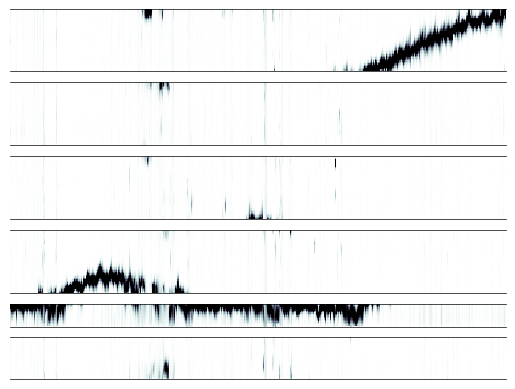

In [436]:
fig, axes = plt.subplots(6, 1, gridspec_kw={"height_ratios": lengths},sharey = False)
    
for ind in range(6):
    ax_ind = axes_ind[ind]
    decode_out = decode_outs[ind]
    
    decode_out.plot(
              x='time', y='position', ax=axes[ax_ind],vmin = 0, vmax = 0.06,
              rasterized=True, cmap='bone_r',infer_intervals = False,
              add_colorbar=False, add_labels=False)
    axes[ax_ind].set_xticks([])
    axes[ax_ind].set_yticks([])
    axes[ax_ind].set_xlabel("")
    axes[ax_ind].set_ylabel("")

    axes[ax_ind].spines['top'].set_linewidth(0.5)
    axes[ax_ind].spines['right'].set_visible(False)
    # Keep the left and bottom borders visible
    axes[ax_ind].spines['left'].set_visible(False)
    axes[ax_ind].spines['bottom'].set_linewidth(0.5)

    position_bins = positions[ind]
    axes[ax_ind].set_ylim([position_bins[0],position_bins[-1]])

In [391]:
sub_gs

GridSpecFromSubplotSpec(6, 1)

In [201]:
decode_out.T.shape

(204, 400)

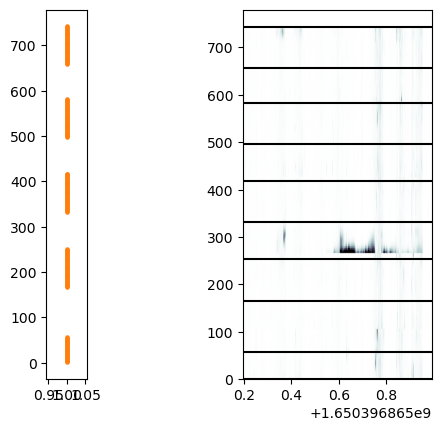

In [204]:
fig, axes = plt.subplots(1, 2, gridspec_kw={"width_ratios": [1,10]},sharey = False)
# decode_out.plot(
#              x='time', y='position', ax=axes[1],vmax = 0.06,
#              rasterized=True, robust=True, cmap='bone_r',infer_intervals = False)

y = np.array(decode_out.position)
axes[0].scatter(np.ones_like(y),y,s=5,color = 'C1')
for segment in region:
    start_end = region[segment]
    axes[1].axhline(start_end[0],color = 'k')
    axes[1].axhline(start_end[1],color = 'k')

[10:35:08][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


array([1.29396953, 1.29110162, 1.2882076 , ..., 1.27982604, 1.28366961,
       1.28752466])